In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset/Employee_Attrition.csv")

In [3]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Stayed


In [4]:
df.shape

(74610, 24)

In [5]:
df.tail()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
74605,13450,44,Female,20,Healthcare,7578,Fair,Medium,Low,2,...,3,Mid,Large,52.0,No,No,No,Fair,Very High,Left
74606,2386,45,Male,26,Technology,8342,Excellent,Very High,Below Average,3,...,4,Mid,Medium,NaN,Yes,No,No,Poor,High,Stayed
74607,36968,28,Female,3,Technology,9763,Poor,Low,Average,0,...,3,Senior,Small,67.0,No,No,No,Poor,Medium,Left
74608,24276,37,Male,3,Education,3644,Fair,High,Average,2,...,4,Entry,Medium,16.0,No,No,No,Excellent,Medium,Stayed
74609,9839,38,Male,28,Media,6172,Good,High,High,0,...,2,Mid,Medium,84.0,No,No,No,Excellent,Low,Stayed


In [6]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size',
       'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='object')

In [7]:
df.dtypes

Employee ID                     int64
Age                             int64
Gender                         object
Years at Company                int64
Job Role                       object
Monthly Income                  int64
Work-Life Balance              object
Job Satisfaction               object
Performance Rating             object
Number of Promotions            int64
Overtime                       object
Distance from Home            float64
Education Level                object
Marital Status                 object
Number of Dependents            int64
Job Level                      object
Company Size                   object
Company Tenure (In Months)    float64
Remote Work                    object
Leadership Opportunities       object
Innovation Opportunities       object
Company Reputation             object
Employee Recognition           object
Attrition                      object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74610 entries, 0 to 74609
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 74610 non-null  int64  
 1   Age                         74610 non-null  int64  
 2   Gender                      74610 non-null  object 
 3   Years at Company            74610 non-null  int64  
 4   Job Role                    74610 non-null  object 
 5   Monthly Income              74610 non-null  int64  
 6   Work-Life Balance           74610 non-null  object 
 7   Job Satisfaction            74610 non-null  object 
 8   Performance Rating          74610 non-null  object 
 9   Number of Promotions        74610 non-null  int64  
 10  Overtime                    74610 non-null  object 
 11  Distance from Home          72698 non-null  float64
 12  Education Level             74610 non-null  object 
 13  Marital Status              746

In [9]:
df.isnull().sum()

Employee ID                      0
Age                              0
Gender                           0
Years at Company                 0
Job Role                         0
Monthly Income                   0
Work-Life Balance                0
Job Satisfaction                 0
Performance Rating               0
Number of Promotions             0
Overtime                         0
Distance from Home            1912
Education Level                  0
Marital Status                   0
Number of Dependents             0
Job Level                        0
Company Size                     0
Company Tenure (In Months)    2413
Remote Work                      0
Leadership Opportunities         0
Innovation Opportunities         0
Company Reputation               0
Employee Recognition             0
Attrition                        0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

Employee ID                   0.000000
Age                           0.000000
Gender                        0.000000
Years at Company              0.000000
Job Role                      0.000000
Monthly Income                0.000000
Work-Life Balance             0.000000
Job Satisfaction              0.000000
Performance Rating            0.000000
Number of Promotions          0.000000
Overtime                      0.000000
Distance from Home            2.562659
Education Level               0.000000
Marital Status                0.000000
Number of Dependents          0.000000
Job Level                     0.000000
Company Size                  0.000000
Company Tenure (In Months)    3.234151
Remote Work                   0.000000
Leadership Opportunities      0.000000
Innovation Opportunities      0.000000
Company Reputation            0.000000
Employee Recognition          0.000000
Attrition                     0.000000
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(112)

In [12]:
df =df .drop_duplicates()

In [13]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 Gender
Gender
Male      40826
Female    33672
Name: count, dtype: int64

 Job Role
Job Role
Technology    19322
Healthcare    17074
Education     15658
Media         11996
Finance       10448
Name: count, dtype: int64

 Work-Life Balance
Work-Life Balance
Good         28158
Fair         22529
Excellent    13432
Poor         10379
Name: count, dtype: int64

 Job Satisfaction
Job Satisfaction
High         37245
Very High    15079
Medium       14717
Low           7457
Name: count, dtype: int64

 Performance Rating
Performance Rating
Average          44719
High             14910
Below Average    11139
Low               3730
Name: count, dtype: int64

 Overtime
Overtime
No     50157
Yes    24341
Name: count, dtype: int64

 Education Level
Education Level
Bachelorâ€™s Degree    22331
Associate Degree       18649
Masterâ€™s Degree      15021
High School            14680
PhD                     3817
Name: count, dtype: int64

 Marital Status
Marital Status
Married     37419
Single      26001

In [14]:
for col in categorical_cols:
    df[col] = df[col].str.strip()

In [15]:
for col in categorical_cols:
    df[col] = df[col].str.title()

In [16]:
numerical_cols = df.select_dtypes(include=np.number).columns

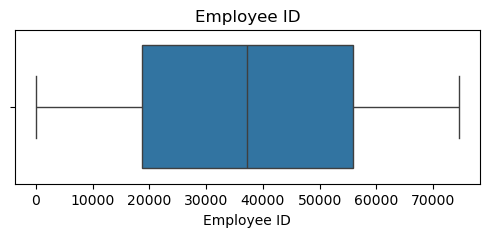

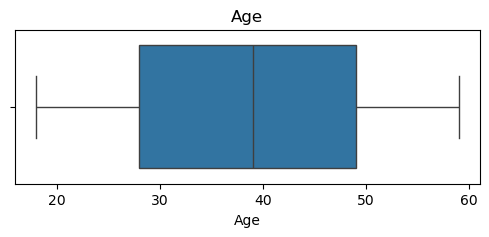

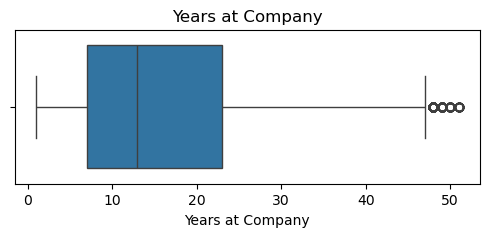

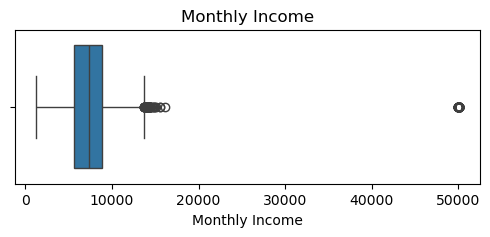

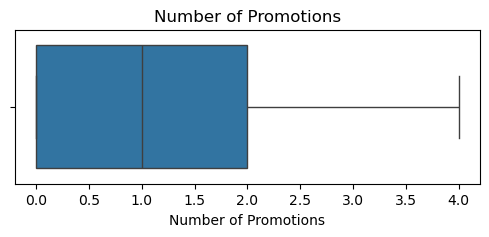

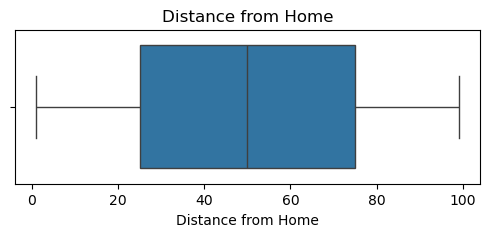

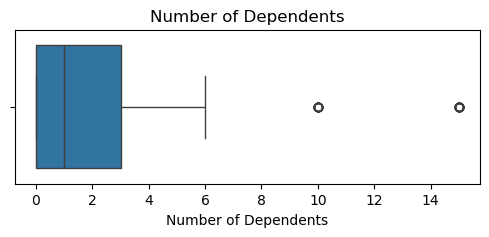

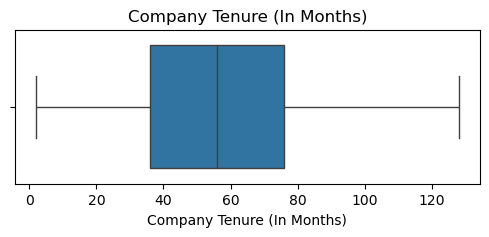

In [17]:
for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [18]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} Outliers")

Employee ID: 0 Outliers
Age: 0 Outliers
Years at Company: 338 Outliers
Monthly Income: 151 Outliers
Number of Promotions: 0 Outliers
Distance from Home: 0 Outliers
Number of Dependents: 48 Outliers
Company Tenure (In Months): 0 Outliers


In [19]:
df.isnull().sum()

Employee ID                      0
Age                              0
Gender                           0
Years at Company                 0
Job Role                         0
Monthly Income                   0
Work-Life Balance                0
Job Satisfaction                 0
Performance Rating               0
Number of Promotions             0
Overtime                         0
Distance from Home            1897
Education Level                  0
Marital Status                   0
Number of Dependents             0
Job Level                        0
Company Size                     0
Company Tenure (In Months)    2381
Remote Work                      0
Leadership Opportunities         0
Innovation Opportunities         0
Company Reputation               0
Employee Recognition             0
Attrition                        0
dtype: int64

In [20]:
df["Distance from Home"] = df["Distance from Home"].fillna(df["Distance from Home"].median())

df["Company Tenure (In Months)"] = df["Company Tenure (In Months)"].fillna(df["Company Tenure (In Months)"].median())

In [21]:
df.isnull().sum()

Employee ID                   0
Age                           0
Gender                        0
Years at Company              0
Job Role                      0
Monthly Income                0
Work-Life Balance             0
Job Satisfaction              0
Performance Rating            0
Number of Promotions          0
Overtime                      0
Distance from Home            0
Education Level               0
Marital Status                0
Number of Dependents          0
Job Level                     0
Company Size                  0
Company Tenure (In Months)    0
Remote Work                   0
Leadership Opportunities      0
Innovation Opportunities      0
Company Reputation            0
Employee Recognition          0
Attrition                     0
dtype: int64

In [22]:
df["Number of Dependents"].describe()

df["Number of Dependents"].value_counts().sort_index()

Number of Dependents
0     22245
1     19315
2     11112
3     10369
4      7617
5      3001
6       791
10       21
15       27
Name: count, dtype: int64

In [23]:
df["Years at Company"].describe()

df["Years at Company"].value_counts().sort_index()

Years at Company
1     3056
2     3039
3     2961
4     2903
5     3084
6     2952
7     2933
8     3015
9     2965
10    2987
11    2893
12    2758
13    2547
14    2349
15    2281
16    2145
17    1994
18    1889
19    1754
20    1729
21    1606
22    1537
23    1557
24    1385
25    1273
26    1255
27    1207
28    1098
29    1057
30     998
31     943
32     872
33     817
34     759
35     638
36     664
37     584
38     560
39     532
40     470
41     433
42     372
43     340
44     266
45     300
46     223
47     180
48     144
49     106
50      55
51      33
Name: count, dtype: int64

In [24]:
df["Monthly Income"].describe()

df["Monthly Income"].value_counts().sort_index()

Monthly Income
1226      1
1253      1
1316      1
1435      1
1503      1
         ..
15552     1
16149     1
50000    30
50020    17
50030    40
Name: count, Length: 9836, dtype: int64

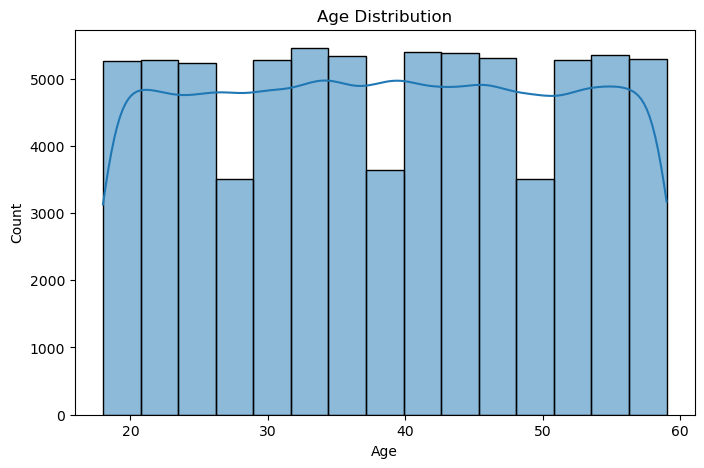

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=15, kde=True)
plt.title("Age Distribution")
plt.show()

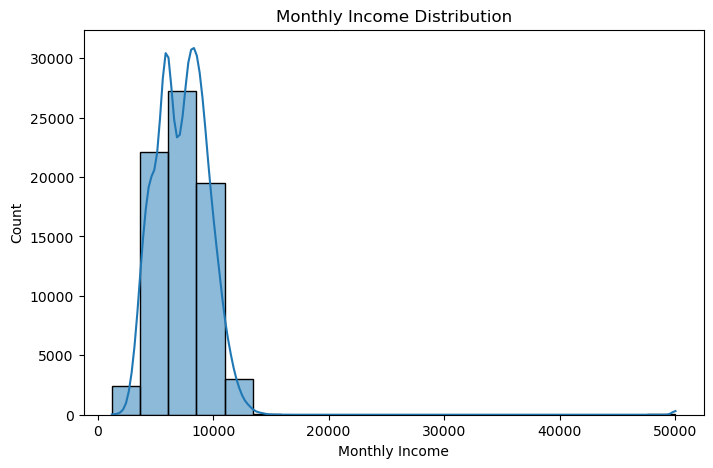

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["Monthly Income"], bins=20, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

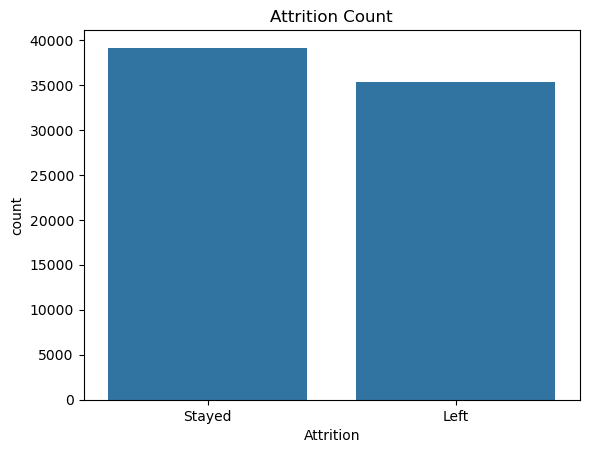

Attrition
Stayed    39128
Left      35370
Name: count, dtype: int64

In [27]:
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Count")
plt.show()

df["Attrition"].value_counts()

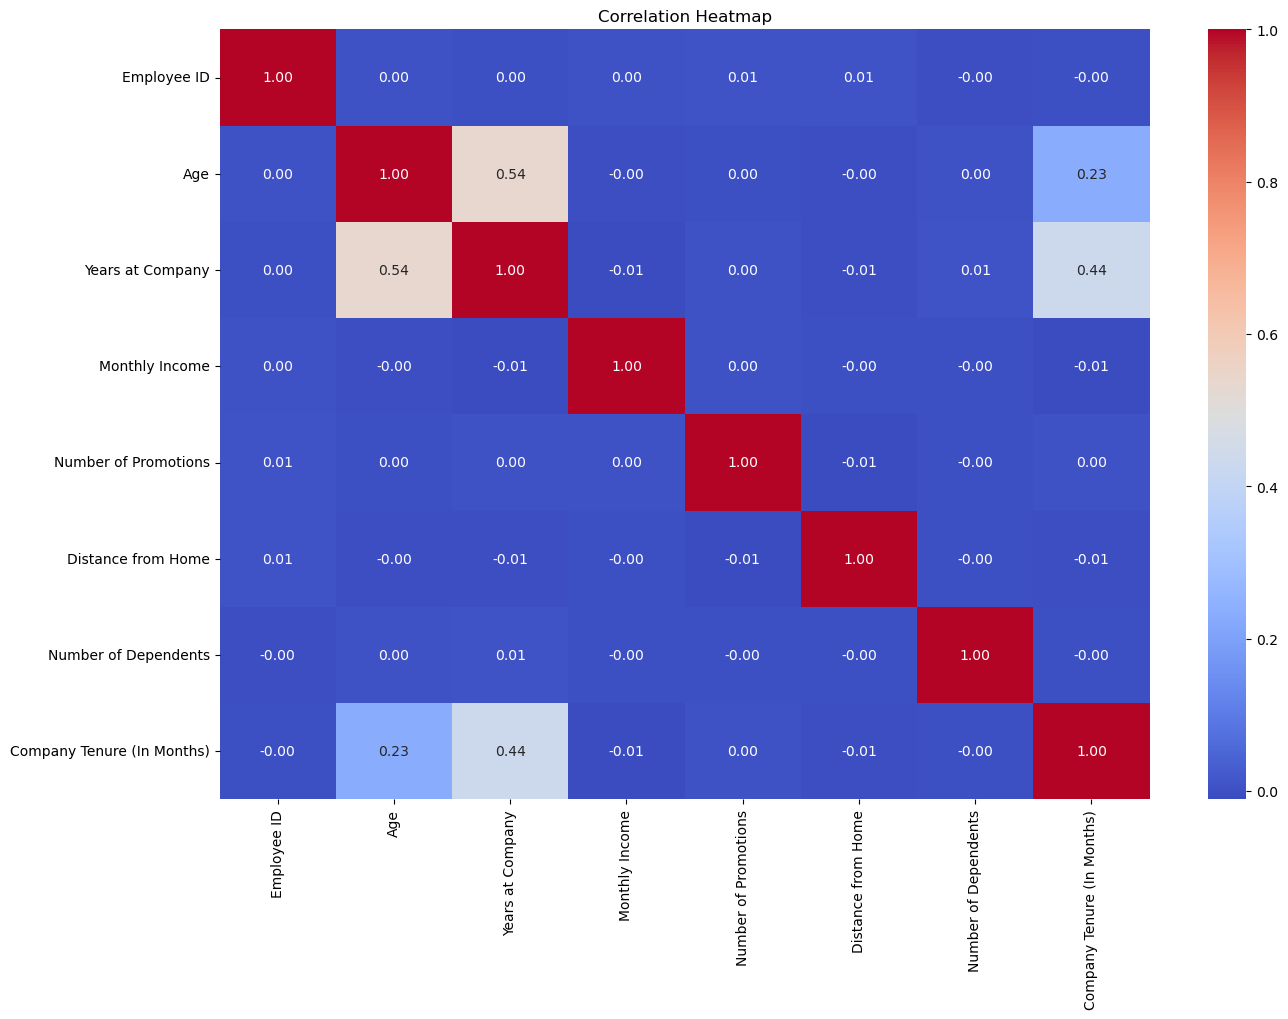

In [28]:
plt.figure(figsize=(15,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

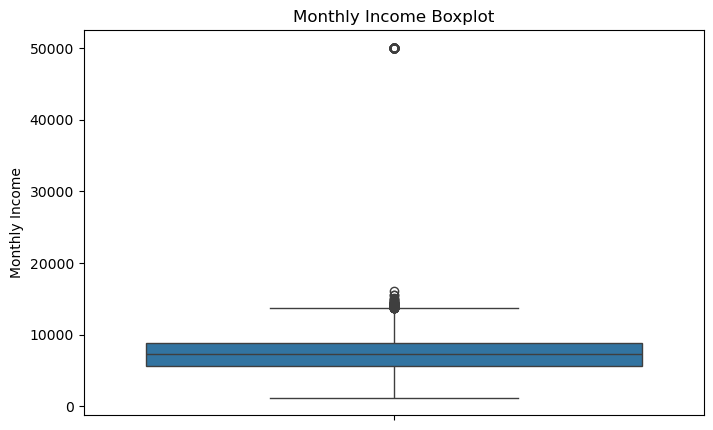

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Monthly Income"])
plt.title("Monthly Income Boxplot")
plt.show()

In [30]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="Attrition",
    user="your_username",
    password="your_password",
    port="5432"
)

cursor = conn.cursor()
print("Connected successfully!")

cursor.execute("SELECT version();")
print(cursor.fetchone())

cursor.execute("SELECT current_database();")
print(cursor.fetchone())

cursor.close()
conn.close()

Connected successfully!
('PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35225, 64-bit',)


In [31]:
cursor.execute("SELECT current_database();")
print(cursor.fetchone())

('Attrition',)


In [33]:
from sqlalchemy import create_engine

DB_USER = "your_username"
DB_PASSWORD = "your_password"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "Attrition"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

df.to_sql(
    "employee_attrition",
    engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")

Data uploaded successfully!
